# P22 spatial ATAC to MERFISH S3R1

This is notebook 2 of 2. It registers the 9,215-observation P22 spatial ATAC
query to an independently clustered Vizgen MERFISH S3R1 reference. The fixed
reference begins with 70,844 cells; the matching half-brain crop contains
35,422 cells in the paper workflow.

The two modalities do not need shared measured features. spAlignDE converts
their independently inferred clusters into comparable masks, pairs structures
with global geometric criteria, and estimates a smooth ATAC-to-ST deformation.

## Notebook order, data, and input contract

Run [spatial ATAC single clustering](atac_st_single_clustering_nb.ipynb) first.
It writes `p22_atac_single_clustered.h5ad`. Prepare the fixed S3R1 reference
with the canonical single-clustering workflow so that it has one selected
cluster column and finite coordinates in `obsm["spatial"]`.

| Role | Dataset | Required AnnData content |
|---|---|---|
| Moving query | P22 spatial ATAC | gene-activity `X`; original x/y coordinates; `obs["cluster_raw"]` from notebook 1 |
| Fixed reference | Vizgen MERFISH S3R1 | cell-by-gene `X`; original x/y coordinates; independently inferred `obs["cluster"]` |

The P22 data are available from the
[UCSC Cell Browser](https://brain-spatial-omics.cells.ucsc.edu/) and
[GEO GSE205055](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE205055).
Download S3R1 from the
[Vizgen MERFISH Mouse Brain Receptor Map](https://info.vizgen.com/mouse-brain-map).

Place the files under `tutorials/cross_modality/atac/output/` and
`data/cross_modality/atac/`, respectively, or set
`SPALIGNDE_ATAC_CLUSTERED_H5AD` and `SPALIGNDE_ST_CLUSTERED_H5AD`.

In [1]:
%matplotlib inline

from pathlib import Path
import os
import time
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import spAlignDE

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from the spAlignDE repository.")


PROJECT_ROOT = find_project_root(Path.cwd())
OUTPUT_DIR = PROJECT_ROOT / "tutorials" / "cross_modality" / "atac" / "output"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
atac_path = Path(
    os.environ.get(
        "SPALIGNDE_ATAC_CLUSTERED_H5AD",
        OUTPUT_DIR / "p22_atac_single_clustered.h5ad",
    )
).expanduser()
st_path = Path(
    os.environ.get(
        "SPALIGNDE_ST_CLUSTERED_H5AD",
        PROJECT_ROOT / "data" / "cross_modality" / "atac" / "merfish_s3r1_clustered.h5ad",
    )
).expanduser()

atac = spAlignDE.load_single_sample_data(atac_path)
st_reference = spAlignDE.load_single_sample_data(st_path)
spAlignDE.validate_single_sample_anndata(atac, cluster_key="cluster_raw", require_cluster=True)
spAlignDE.validate_single_sample_anndata(st_reference, cluster_key="cluster", require_cluster=True)

inputs = pd.DataFrame(
    {
        "role": ["moving query", "fixed reference"],
        "dataset": ["P22 spatial ATAC", "MERFISH S3R1"],
        "observations": [atac.n_obs, st_reference.n_obs],
        "features": [atac.n_vars, st_reference.n_vars],
        "structures": [atac.obs["cluster_raw"].nunique(), st_reference.obs["cluster"].nunique()],
    }
)
display(inputs)

,role,dataset,observations,features,structures
0,moving query,P22 spatial ATAC,9215,24027,16
1,fixed reference,MERFISH S3R1,70844,649,19


## Stage 1 — independent structures

ATAC and ST are clustered separately within their own molecular spaces. The
ATAC panel shows the raw BANKSY labels from notebook 1; the ST panel shows the
independently prepared S3R1 labels. Similar colors across panels do not imply
a match at this stage.

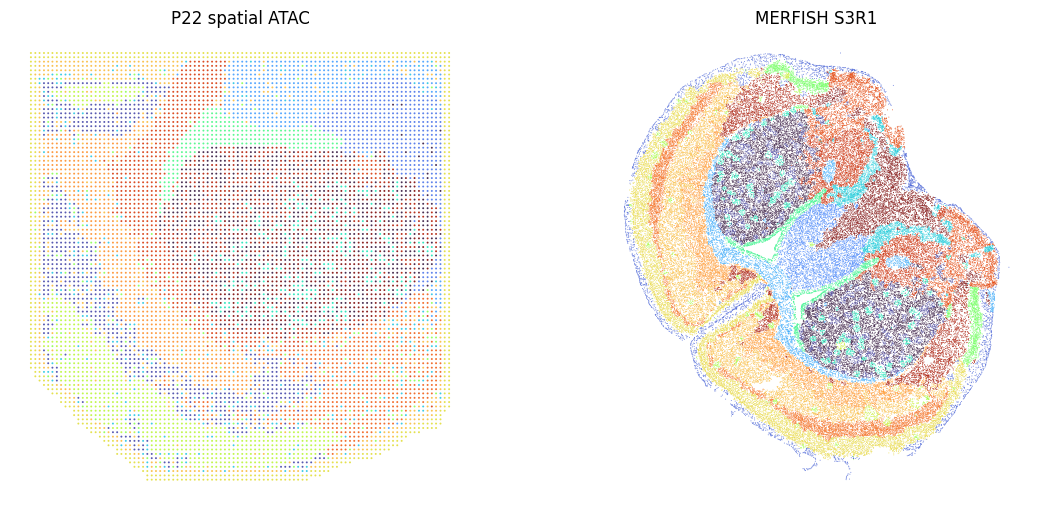

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5), constrained_layout=True)
for axis, adata, key, title, size in [
    (axes[0], atac, "cluster_raw", "P22 spatial ATAC", 2.0),
    (axes[1], st_reference, "cluster", "MERFISH S3R1", 0.45),
]:
    labels = pd.Categorical(adata.obs[key].astype(str))
    axis.scatter(
        adata.obsm["spatial"][:, 0], adata.obsm["spatial"][:, 1],
        c=labels.codes, cmap="turbo", s=size, alpha=0.88,
        edgecolors="none", rasterized=True,
    )
    axis.set_title(title)
    axis.set_aspect("equal")
    axis.axis("off")
fig.savefig(FIGURE_DIR / "atac_st_independent_structures.png", dpi=220, bbox_inches="tight")
plt.show()

## Stage 2 — global pre-alignment and matching field of view

The paper experiment uses one global similarity transform for each modality,
then retains the left half of the transformed ST brain because the ATAC assay
covers a partial section. The shared analysis canvas is scaled by 0.25 and
padded by 10 pixels.

```text
ST:   rotation = -125°, scale = 1.0, translation = (0, 0)
ATAC: rotation =  -90°, scale = 1.6, translation = (-2600, -3300)
ST crop: x-axis left half at the 0.5 quantile
```

These are global, sample-level initialization parameters. They neither assign
region identities nor give a hippocampal or other anatomical structure a
special weight. If this initialization is unsuitable for a new sample, tune a
global transform with the package's interactive manual pre-alignment first,
then record the selected values in `ATACSTPrealignmentConfig`.

ATAC observations retained: 9,215
ST observations after half-brain crop: 35,422
Shared canvas (height, width): (1478, 1027)


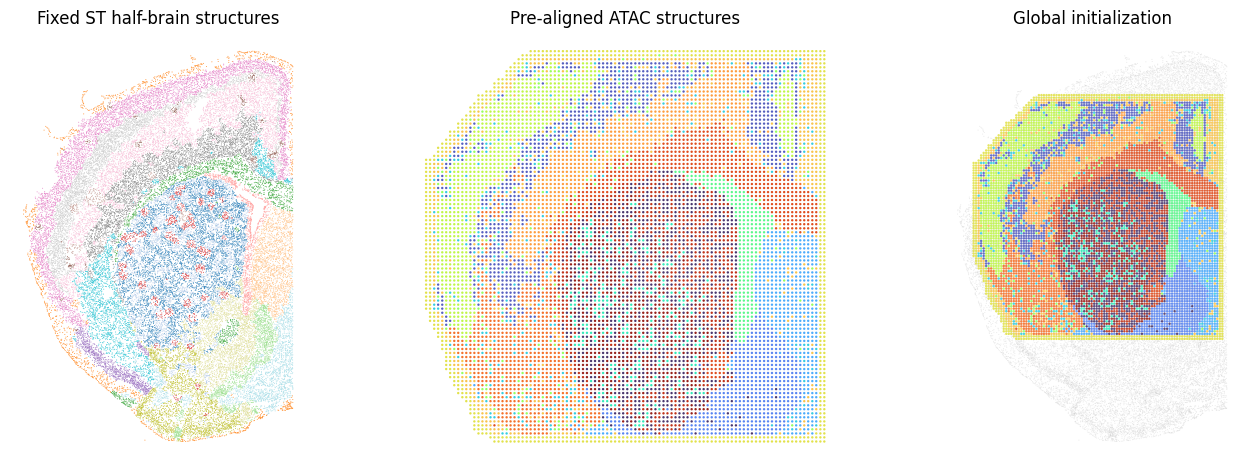

In [4]:
prealignment_config = spAlignDE.ATACSTPrealignmentConfig(
    st_transform=spAlignDE.ManualPrealignmentConfig(
        scale=1.0, theta_deg=-125.0, translation_x=0.0, translation_y=0.0
    ),
    atac_transform=spAlignDE.ManualPrealignmentConfig(
        scale=1.6, theta_deg=-90.0, translation_x=-2600.0, translation_y=-3300.0
    ),
    reference_crop_axis="x",
    reference_crop_side="left",
    reference_crop_quantile=0.5,
    raster_scale=0.25,
    canvas_padding=10,
)

prealigned = spAlignDE.prealign_atac_to_st(
    atac,
    st_reference,
    config=prealignment_config,
    atac_cluster_key="cluster_raw",
    st_cluster_key="cluster",
)

print("ATAC observations retained:", f"{prealigned.atac.n_obs:,}")
print("ST observations after half-brain crop:", f"{prealigned.st_reference.n_obs:,}")
print("Shared canvas (height, width):", prealigned.canvas_shape_hw)

fig, axes = spAlignDE.plot_atac_st_prealignment(
    prealigned,
    atac_cluster_key="cluster_raw",
    st_cluster_key="cluster",
)
fig.savefig(FIGURE_DIR / "atac_st_global_prealignment.png", dpi=220, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "atac_st_global_prealignment.svg", bbox_inches="tight")
plt.show()

### How to adapt the partial-field pre-alignment

Tune the global ST and ATAC similarity transforms before the reference crop.
Then choose `reference_crop_axis`, `reference_crop_side` and
`reference_crop_quantile` so both modalities contain the same anatomical field
of view. A crop with good point-cloud overlap but different anatomy is not a
valid initialization.

`raster_scale` converts transformed coordinates to the common canvas. A larger
value retains more spatial detail and increases memory. After changing it,
reinterpret every pixel-distance threshold, `kernel_scale` and velocity-grid
spacing in the new canvas units. Use `canvas_padding` only to keep supported
deformation away from the canvas boundary; it does not correct alignment.

## Stage 3 — rasterize and pair independently inferred structures

For every ATAC and ST cluster, spAlignDE removes sparse point outliers,
rasterizes the point cloud, smooths and closes the mask, fills holes, and
retains its principal connected components. Narrow structures receive a more
conservative mask recipe than broad structures.

Every cross-modality candidate pair is evaluated with one global score:

```text
0.35 × signed-distance correlation
+ 0.25 × Chamfer similarity
+ 0.30 × area similarity
+ 0.10 × Dice overlap
```

A global logistic gate downweights candidates with large boundary distance.
Pairs must have score ≥ 0.25 and Dice ≥ 0.01; greedy selection then enforces a
one-to-one mapping. These weights and gates are applied identically to every
structure—there are no region-specific labels or anatomical weights.

## Stage 4 — structure-guided S-LDDMM

Accepted masks are converted to clipped signed-distance-transform channels.
Inverse-area channel balancing prevents a large structure from dominating the
loss while remaining a global rule shared by every channel. S-LDDMM then
estimates a smooth diffeomorphic field and maps all ATAC observations, not only
the points belonging to matched masks.

The paper settings are `nt=8`, `niter=500`, diffeomorphic start 20,
`a=100`, `p=2`, velocity-grid spacing 40, `epL=2e-11`, `epT=2e-5`,
`epM=1e3`, `sigmaR=1e6`, and `sigmaM=0.5`.

The optimizer applies one global numerical-stability policy: clip the momentum
gradient, reduce the common step scale when total energy rises, reject a
non-finite or singular affine update, and restore the lowest-energy checkpoint.
These safeguards do not inspect cluster names or anatomical regions.

In [5]:
alignment_config = spAlignDE.ATACSTAlignmentConfig(
    sdf_weight=0.35,
    chamfer_weight=0.25,
    area_weight=0.30,
    dice_weight=0.10,
    chamfer_gate_center=16.0,
    chamfer_gate_scale=6.0,
    pair_score_threshold=0.25,
    pair_dice_threshold=0.01,
    maximum_pairs=20,
    time_steps=8,
    iterations=500,
    diffeomorphic_start=20,
    kernel_scale=100.0,
    kernel_power=2.0,
    velocity_grid_spacing=40.0,
    affine_linear_lr=2e-11,
    affine_translation_lr=2e-5,
    momentum_lr=1e3,
    deformation_regularization=1e6,
    matching_scale=0.5,
)

started = time.perf_counter()
result = spAlignDE.align_atac_to_st(
    prealigned,
    config=alignment_config,
    atac_cluster_key="cluster_raw",
    st_cluster_key="cluster",
    output_dir=OUTPUT_DIR / "alignment",
    verbose=False,
)
elapsed = time.perf_counter() - started

print(f"Alignment runtime: {elapsed / 60:.2f} min")
print("Accepted structure pairs:", len(result.matched_pairs))
display(
    result.matched_pairs[
        [
            "st_structure", "atac_structure", "align_score", "sdf_corr",
            "chamfer_distance", "area_sim", "dice",
        ]
    ].round(4)
)

Alignment runtime: 1.31 min
Accepted structure pairs: 5


,st_structure,atac_structure,align_score,sdf_corr,chamfer_distance,area_sim,dice
0,1,0,0.3282,0.6239,34.9764,0.8441,0.8119
1,3,1,0.3164,0.5020,30.9328,0.9354,0.4230
2,4,5,0.2714,0.5262,38.1772,0.7568,0.4866
3,12,11,0.2560,0.5674,66.9920,0.7332,0.6666
4,2,2,0.2531,0.4016,52.9165,0.9333,0.4178


### How to adapt ATAC-to-ST pairing and S-LDDMM

- Inspect structure masks after outlier filtering before tuning pair scores.
  `density_neighbors` and `density_mad_multiplier` control sparse-coordinate
  filtering; a smaller MAD multiplier is stricter.
- SDF, Chamfer, area and Dice weights define one global pairing rule.
  `pair_score_threshold` and `pair_dice_threshold` are acceptance gates. Do not
  loosen them until rejected candidate masks have been reviewed.
- `channel_area_power` strengthens inverse-area balancing as it approaches one;
  `channel_uniform_mix` moves weights toward equality. These settings can
  protect narrow masks without assigning an anatomy-specific weight.
- `kernel_scale=100` is legacy `a`; `velocity_grid_spacing=40` is legacy
  `grid_step`. Both use the cropped raster-canvas units. Larger values are
  smoother/coarser; smaller values are more local and more expensive.
- `time_steps=8` controls flow integration. Tune `iterations` and
  `momentum_lr` only after pre-alignment and accepted pairs pass QC; use the
  rollback and best-checkpoint diagnostics to detect instability.

## Stage 5 — visual quality control

The first figure assigns one shared color to each accepted ST/ATAC structure
pair. Gray points were not used as matched channels but are still carried by
the smooth deformation. The second figure compares the global initialization
with the final ATAC coordinates over the fixed ST reference.

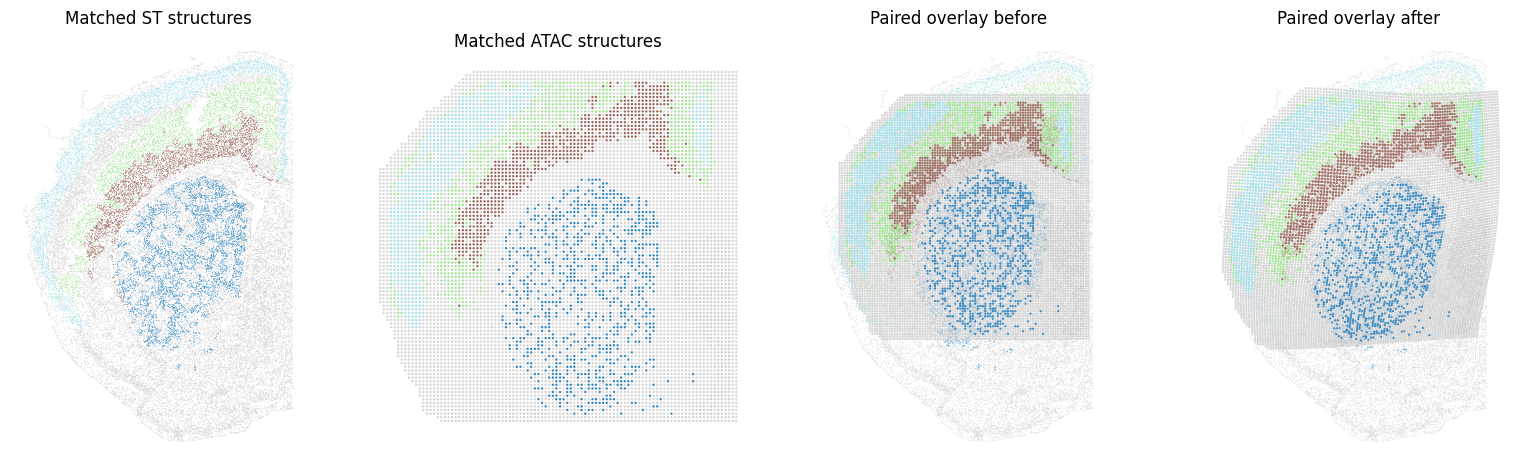

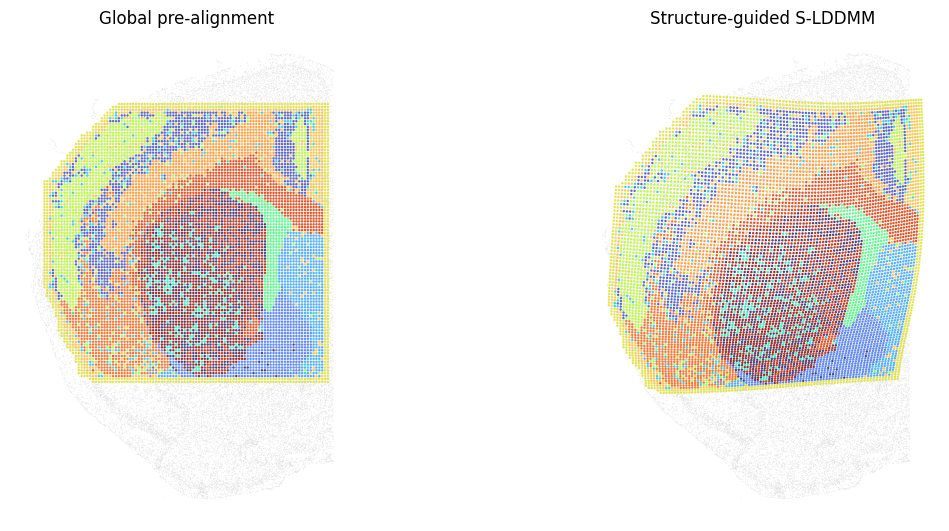

In [6]:
fig, axes = spAlignDE.plot_atac_st_matched_structures(
    result,
    atac_cluster_key="cluster_raw",
    st_cluster_key="cluster",
)
fig.savefig(FIGURE_DIR / "atac_st_matched_structure_pairs.png", dpi=220, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "atac_st_matched_structure_pairs.svg", bbox_inches="tight")
plt.show()

fig, axes = spAlignDE.plot_atac_st_alignment(
    result,
    atac_cluster_key="cluster_raw",
)
fig.savefig(FIGURE_DIR / "atac_st_alignment_before_after.png", dpi=220, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "atac_st_alignment_before_after.svg", bbox_inches="tight")
plt.show()

## Outputs and interpretation

The aligned ATAC AnnData preserves the original assay and coordinates and
adds the package-wide coordinate contract:

- `x_prealigned`, `y_prealigned`: ATAC after the recorded global transform;
- `x_aligned`, `y_aligned`: final ATAC coordinates in the ST analysis frame.

The cropped ST reference receives the same four columns; because it is fixed,
its prealigned and aligned values are identical. Provenance is stored under
`uns["spAlignDE"]["atac_to_st"]`.

`alignment/` also contains the aligned/query and fixed/reference H5AD files,
all candidate scores, accepted one-to-one pairs, mask summaries, and a JSON
manifest. The accepted masks are optimization inputs; downstream label
agreement or local-neighborhood preservation is an independent evaluation and
is not used to tune the deformation.

For a new section, first inspect the global pre-alignment and pair overlay. If
the tissue fields do not correspond, revise the global initialization or crop
before changing the globally shared score weights.

In [7]:
output_columns = ["x_prealigned", "y_prealigned", "x_aligned", "y_aligned"]
assert all(column in result.atac.obs for column in output_columns)
assert result.atac.n_obs == atac.n_obs
assert result.atac.obs[output_columns].notna().all().all()

output_summary = pd.DataFrame(
    {
        "file": [
            "atac_to_st_aligned.h5ad",
            "st_reference_analysis_frame.h5ad",
            "matched_structure_pairs.csv",
            "candidate_structure_pairs.csv",
            "atac_mask_summary.csv / st_mask_summary.csv",
            "alignment_manifest.json",
        ],
        "content": [
            "ATAC assay plus standardized coordinates",
            "fixed cropped ST reference and analysis-frame coordinates",
            "accepted one-to-one structure pairs",
            "all global geometric pair scores",
            "mask construction diagnostics",
            "pre-alignment, pairing, and S-LDDMM provenance",
        ],
    }
)
display(output_summary)
print("Validated all", f"{result.atac.n_obs:,}", "ATAC observations.")

,file,content
0,atac_to_st_aligned.h5ad,ATAC assay plus standardized coordinates
1,st_reference_analysis_frame.h5ad,fixed cropped ST reference and analysis-frame ...
2,matched_structure_pairs.csv,accepted one-to-one structure pairs
3,candidate_structure_pairs.csv,all global geometric pair scores
4,atac_mask_summary.csv / st_mask_summary.csv,mask construction diagnostics
5,alignment_manifest.json,"pre-alignment, pairing, and S-LDDMM provenance"


Validated all 9,215 ATAC observations.
